In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/sample_data/HR_comma.csv')
df


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
#dum=pd.get_dummies(df.department,df.salary).....wrong syntax
dum = pd.get_dummies(df[['Department', 'salary']])
dum

,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low,salary_medium
0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False,False,False,False,True
2,False,False,False,False,False,False,False,True,False,False,False,False,True
3,False,False,False,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,True,False,False,True,False
14995,False,False,False,False,False,False,False,False,True,False,False,True,False
14996,False,False,False,False,False,False,False,False,True,False,False,True,False
14997,False,False,False,False,False,False,False,False,True,False,False,True,False


In [ ]:
merged=pd.concat([df,dum],axis='columns')
merged

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,...,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,sales,low,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,sales,low,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,sales,low,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False


In [ ]:
final=merged.drop(['Department','salary','salary_medium'],axis='columns')
final

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,False,True,False,False,False,True
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,False,True,False,False,False,False
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,False,True,False,False,False,False
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,False,True,False,False,False,True
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,False,False,False,False,False,False,False,False,True,False,False,True
14995,0.37,0.48,2,160,3,0,1,0,False,False,False,False,False,False,False,False,True,False,False,True
14996,0.37,0.53,2,143,3,0,1,0,False,False,False,False,False,False,False,False,True,False,False,True
14997,0.11,0.96,6,280,4,0,1,0,False,False,False,False,False,False,False,False,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(final[['satisfaction_level','last_evaluation','number_project','average_montly_hours','time_spend_company','Work_accident','promotion_last_5years','Department_IT','Department_RandD','Department_accounting','Department_hr','Department_management','Department_marketing','Department_product_mng','Department_sales','Department_support','Department_technical','salary_high','salary_low']],df.left,train_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
model.score(x_test,y_test)

0.7788333333333334

In [ ]:
coefficients = model.coef_
print("Model Coefficients:")
print(coefficients)

Model Coefficients:
[[-3.98644775  0.5149411  -0.26318451  0.00456763  0.2420339  -1.35005325
  -1.57986273 -0.17405861 -0.82601899  0.06429606  0.29467871 -0.01324121
   0.44046732  0.03562447 -0.08835     0.07375633  0.10012399 -1.34170331
   0.50652601]]


In [ ]:
feature_names = x_train.columns
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients[0]})
print("Coefficients with Feature Names:")
print(coefficients_df)

Coefficients with Feature Names:
                   Feature  Coefficient
0       satisfaction_level    -3.986448
1          last_evaluation     0.514941
2           number_project    -0.263185
3     average_montly_hours     0.004568
4       time_spend_company     0.242034
5            Work_accident    -1.350053
6    promotion_last_5years    -1.579863
7            Department_IT    -0.174059
8         Department_RandD    -0.826019
9    Department_accounting     0.064296
10           Department_hr     0.294679
11   Department_management    -0.013241
12    Department_marketing     0.440467
13  Department_product_mng     0.035624
14        Department_sales    -0.088350
15      Department_support     0.073756
16    Department_technical     0.100124
17             salary_high    -1.341703
18              salary_low     0.506526


**Reasoning**:
To visualize the coefficients, I need to import the `matplotlib.pyplot` library.



In [ ]:
import matplotlib.pyplot as plt

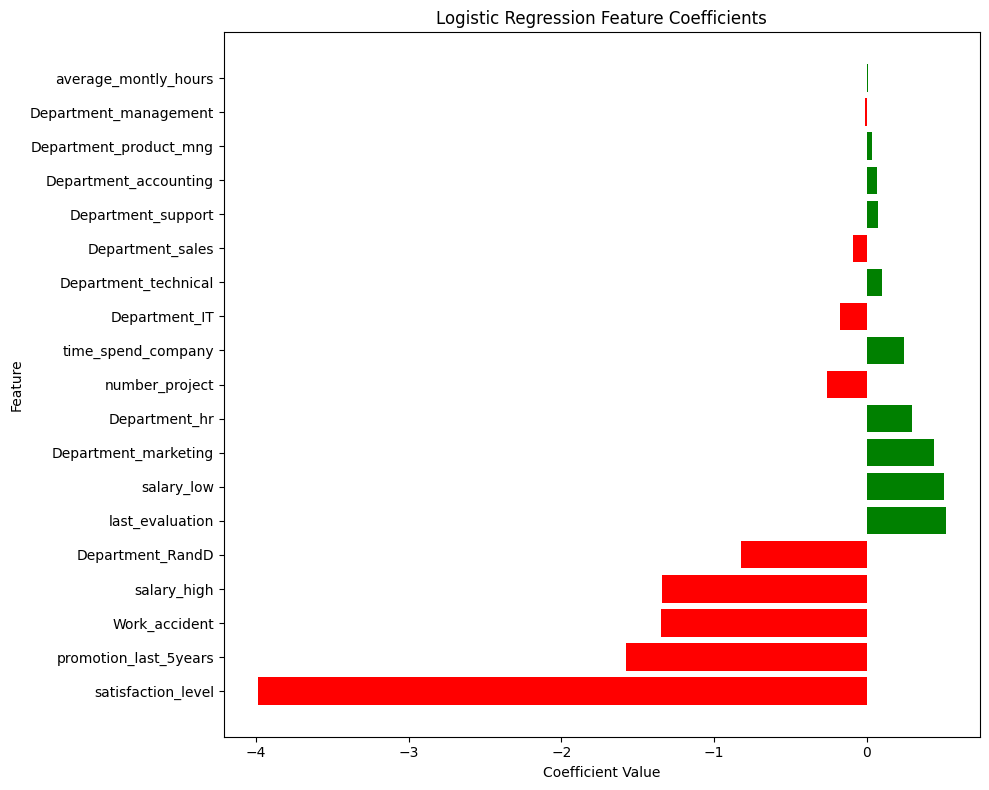

In [ ]:
coefficients_df['Absolute_Coefficient'] = abs(coefficients_df['Coefficient'])
sorted_coefficients = coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(sorted_coefficients['Feature'], sorted_coefficients['Coefficient'], color=['red' if x < 0 else 'green' for x in sorted_coefficients['Coefficient']])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Coefficients')
plt.tight_layout()
plt.show()


In [ ]:
import pickle
pickle.dump(model, open("hr.pkl", "wb"))